# **Uploading dataset**

In [ ]:
import os
import zipfile
import shutil

from collections import defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm


import random
import math
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

from tensorflow.keras import layers, models


from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image

import numpy as np

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

**Mounting my personal Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Unzipping Dataset**

In [ ]:
zip_drive_path = '/content/drive/MyDrive/ProgettoSE/image_dataset_SE/vegnet.ZIP'
extract_path = '/content/image_dataset_SE'

# Cancella eventuali vecchie estrazioni
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

# Estrai lo zip
with zipfile.ZipFile(zip_drive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset estratto in: {extract_path}")

Dataset estratto in: /content/image_dataset_SE


**Ananlizing Classes and Subclasses**

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

dataset_path = '/content/image_dataset_SE/New VegNet'

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Conta immagini per (classe principale / stato)
class_counts = defaultdict(lambda:defaultdict(int))   # crea un dizionario in cui ogni chiave non esistente ha valore iniziale 0 (serve pre contare le immagini per categoria)

for main_class in sorted(os.listdir(dataset_path)):
    main_class_path = os.path.join(dataset_path, main_class)
    print(f"Classe: {main_class_path}")
    if os.path.isdir(main_class_path):    # controllo se main_class_path è una directory
        for subclass in sorted(os.listdir(main_class_path)):
            subclass_path = os.path.join(main_class_path, subclass)
            if os.path.isdir(subclass_path):
                # lista di file in subclass_path (Damaged, Dried, Ripe, ecc...)
                image_files = [
                    f for f in os.listdir(subclass_path)
                    if os.path.isfile(os.path.join(subclass_path, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))   # verifica l'estensione dei file e ignora maiuscole/minuscole
                ]
                class_counts[main_class][subclass] = len(image_files)
                count = len(image_files)

# Stampa risultati
for main_class, subclasses in class_counts.items():  # restituisce una lista di coppie chiave-valore sotto forma di tuple.
    print(f"\n📁 {main_class}")
    for subclass, count in subclasses.items():
        print(f"   └── {subclass}: {count} immagini")

# Calcola totale complessivo
total_images = sum(
    count
    for subclasses in class_counts.values()
    for count in subclasses.values()
)

print(f"\n🧮 Totale immagini complessive: {total_images}")


Classe: /content/image_dataset_SE/New VegNet/1. Bell Pepper
Classe: /content/image_dataset_SE/New VegNet/2. Chile Pepper
Classe: /content/image_dataset_SE/New VegNet/3. New Mexico Green Chile
Classe: /content/image_dataset_SE/New VegNet/4. Tomato

📁 1. Bell Pepper
   └── Damaged: 31 immagini
   └── Dried: 296 immagini
   └── Old: 349 immagini
   └── Ripe: 448 immagini
   └── Unripe: 52 immagini

📁 2. Chile Pepper
   └── Damaged: 121 immagini
   └── Dried: 593 immagini
   └── Old: 200 immagini
   └── Ripe: 183 immagini
   └── Unripe: 189 immagini

📁 3. New Mexico Green Chile
   └── Damaged: 138 immagini
   └── Dried: 500 immagini
   └── Old: 261 immagini
   └── Ripe: 201 immagini
   └── Unripe: 227 immagini

📁 4. Tomato
   └── Damaged: 27 immagini
   └── Dried: 0 immagini
   └── Old: 1234 immagini
   └── Ripe: 955 immagini
   └── Unripe: 145 immagini

🧮 Totale immagini complessive: 6150


**Plotting Classes and Subclasses**

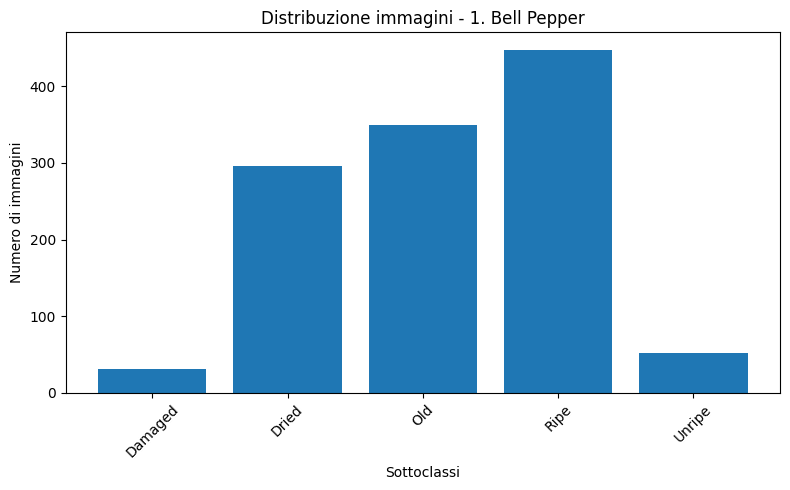

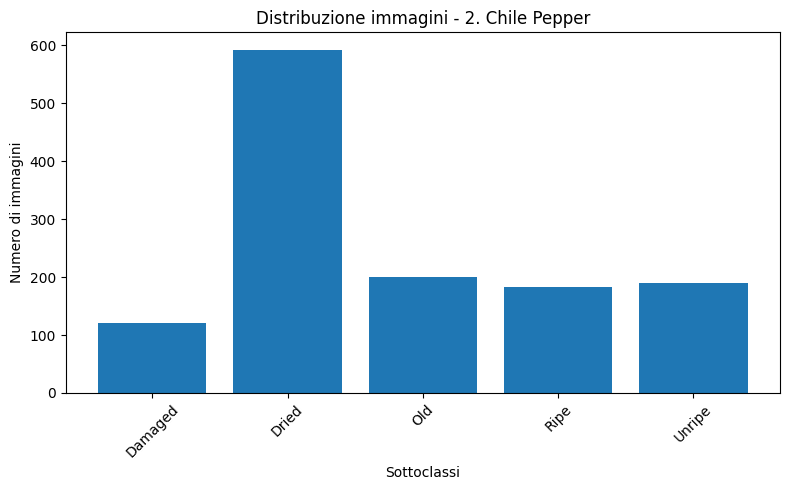

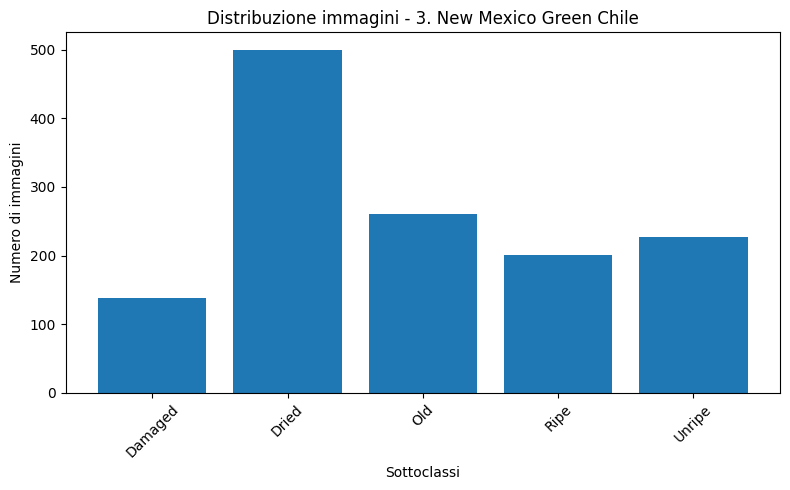

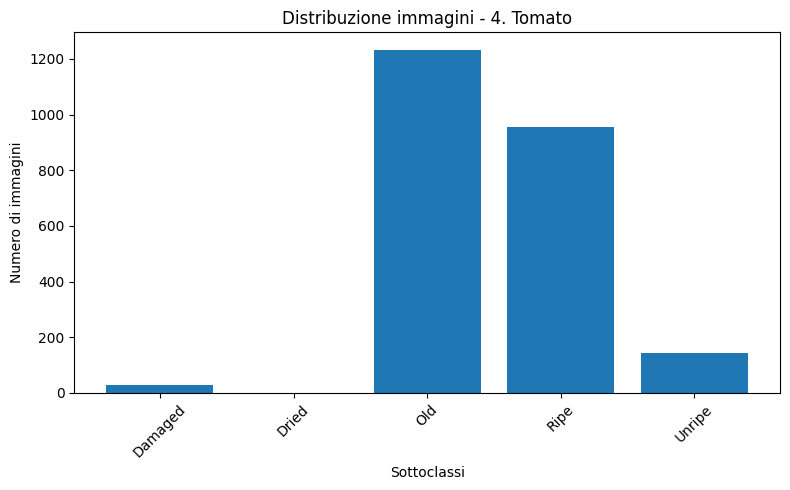

In [ ]:
# Genera un grafico per ogni classe
for main_class, subclasses in class_counts.items():
    labels = list(subclasses.keys())
    counts = list(subclasses.values())

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts)
    plt.title(f"Distribuzione immagini - {main_class}")
    plt.xlabel("Sottoclassi")
    plt.ylabel("Numero di immagini")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# **Data Augmentation**

Utilizzo il metodo ImageDataGenerator.flow(...) che applica in modo randomico una combinazione delle trasformazioni che definisco.

In particolare calcolo dinamicamente quante nuove immagini "augmentate" generare per singola immagine originale.

In [ ]:
# Siccome il dataset originale è fortemente sbilanciato sia nelle classi principali che in alcune delle sottoclassi
# cerco di bilanciarlo con la generazione di immagini "augmentate" in modo che le classi e sottoclassi abbiano
# un numero di immagini il piu vicino possibile.
# In particolare voglio ottenere circa 600 immagini per sottoclasse per un totale di circa 3000 immagini per classe principale.
# Il numero di immagini che vengono generate da una singola immagine è gestito in modo dinamico, così se una sottoclasse contiene
# originariamente poche immagini, da quest'ultime verranno generate molte immagini fino ad arrivare a 600.

import os
import shutil
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

SOURCE_DIR = "/content/image_dataset_SE/New VegNet"
OUTPUT_DIR = "/content/image_dataset_SE/Final Dataset Balanced"
TARGET_COUNT = 600

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)

for main_class in sorted(os.listdir(SOURCE_DIR)):
    main_path = os.path.join(SOURCE_DIR, main_class)
    if not os.path.isdir(main_path):
        continue

    for subclass in sorted(os.listdir(main_path)):
        sub_path = os.path.join(main_path, subclass)
        if not os.path.isdir(sub_path):
            continue

        images = [f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        current_count = len(images)
        save_path = os.path.join(OUTPUT_DIR, main_class, subclass)
        os.makedirs(save_path, exist_ok=True)

        # Copia immagini originali
        for fname in images:
            shutil.copy(os.path.join(sub_path, fname), os.path.join(save_path, fname))

        if current_count >= TARGET_COUNT:
            print(f"✅ {main_class}/{subclass}: {current_count} immagini – OK")
            continue

        needed = TARGET_COUNT - current_count
        print(f"🚀 Augmenting {main_class}/{subclass}: {current_count} → {TARGET_COUNT}")
        generated = 0

        for fname in tqdm(images, desc=f"{main_class}/{subclass}"):
            if generated >= needed:
                break

            img_path = os.path.join(sub_path, fname)
            img = load_img(img_path)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            # Calcola quanti augment generare da questa immagine
            aug_needed = int((TARGET_COUNT - current_count) / current_count) + 1

            i = 0
            for batch in datagen.flow(x, batch_size=1):
                out_name = f"{os.path.splitext(fname)[0]}_aug{generated}.jpg"
                save_img(os.path.join(save_path, out_name), batch[0])
                generated += 1
                i += 1
                if i >= aug_needed or generated >= needed:
                    break

print("\n✅ Bilanciamento completo!")



🚀 Augmenting 1. Bell Pepper/Damaged: 31 → 600


1. Bell Pepper/Damaged:  97%|█████████▋| 30/31 [00:10<00:00,  2.87it/s]


🚀 Augmenting 1. Bell Pepper/Dried: 296 → 600


1. Bell Pepper/Dried:  51%|█████▏    | 152/296 [00:04<00:04, 31.87it/s]


🚀 Augmenting 1. Bell Pepper/Old: 349 → 600


...

🚀 Augmenting 4. Tomato/Dried: 0 → 600


4. Tomato/Dried: 0it [00:00, ?it/s]


✅ 4. Tomato/Old: 1234 immagini – OK
✅ 4. Tomato/Ripe: 955 immagini – OK
🚀 Augmenting 4. Tomato/Unripe: 145 → 600


4. Tomato/Unripe:  79%|███████▊  | 114/145 [00:07<00:01, 16.24it/s]


✅ Bilanciamento completo!


**Analazing Final Dataset**

Come si può notare dai grafici, il dataset finale risulta molto più bilanciato rispetto a quello iniziale.
Le classi principali posseggono circa 3000 immagini (tranne tomato 3389), mentre le sottoclassi hanno circa tutte 600 immagini.

Classe: /content/image_dataset_SE/Final Dataset Balanced/1. Bell Pepper
Classe: /content/image_dataset_SE/Final Dataset Balanced/2. Chile Pepper
Classe: /content/image_dataset_SE/Final Dataset Balanced/3. New Mexico Green Chile
Classe: /content/image_dataset_SE/Final Dataset Balanced/4. Tomato

📁 1. Bell Pepper
   └── Damaged: 600 immagini
   └── Dried: 600 immagini
   └── Old: 600 immagini
   └── Ripe: 600 immagini
   └── Unripe: 600 immagini
   └── Totale: 3000 immagini

📁 2. Chile Pepper
   └── Damaged: 600 immagini
   └── Dried: 600 immagini
   └── Old: 600 immagini
   └── Ripe: 600 immagini
   └── Unripe: 600 immagini
   └── Totale: 3000 immagini

📁 3. New Mexico Green Chile
   └── Damaged: 600 immagini
   └── Dried: 600 immagini
   └── Old: 600 immagini
   └── Ripe: 600 immagini
   └── Unripe: 600 immagini
   └── Totale: 3000 immagini

📁 4. Tomato
   └── Damaged: 600 immagini
   └── Dried: 0 immagini
   └── Old: 1234 immagini
   └── Ripe: 955 immagini
   └── Unripe: 600 immagini


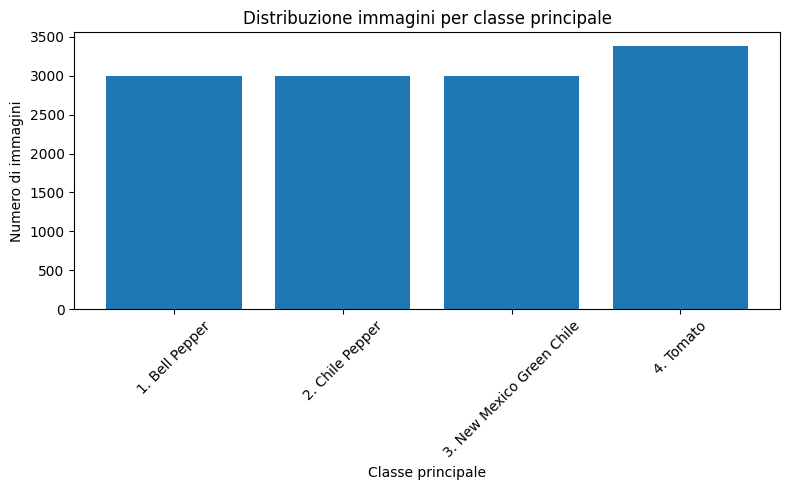

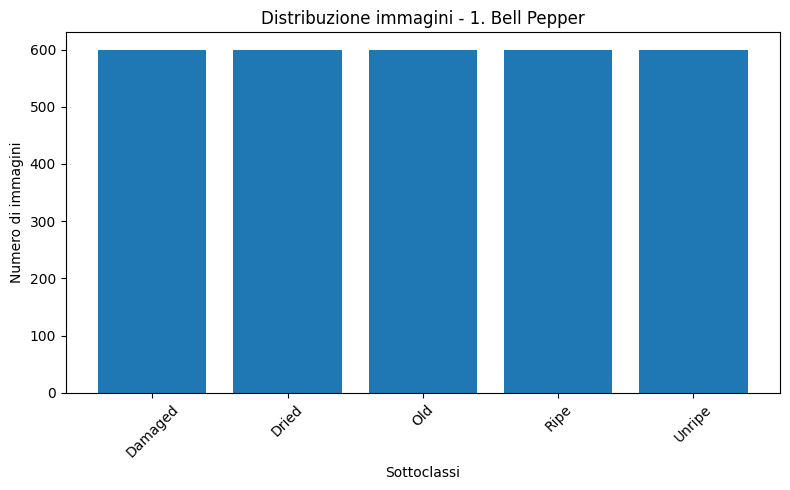

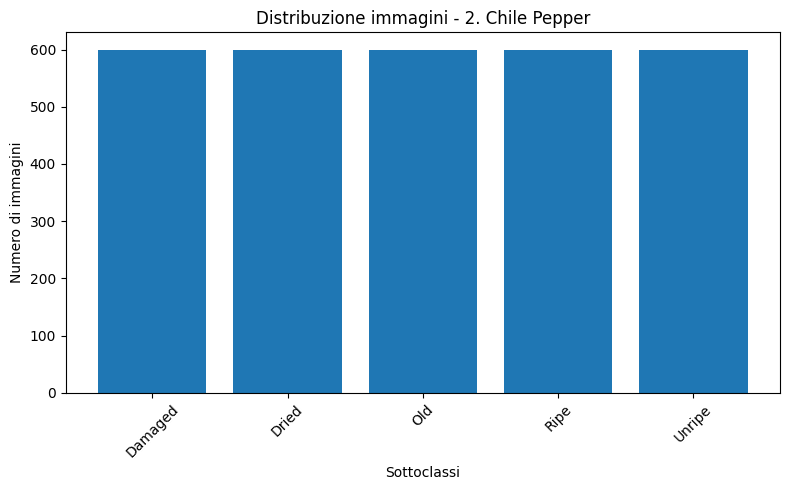

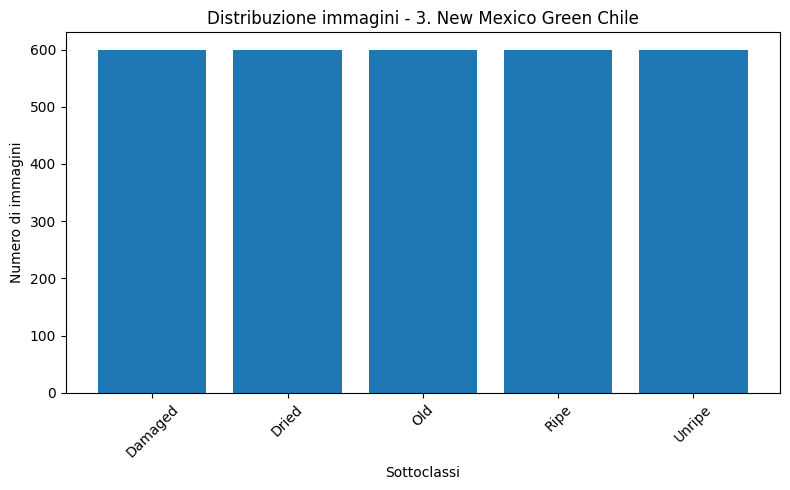

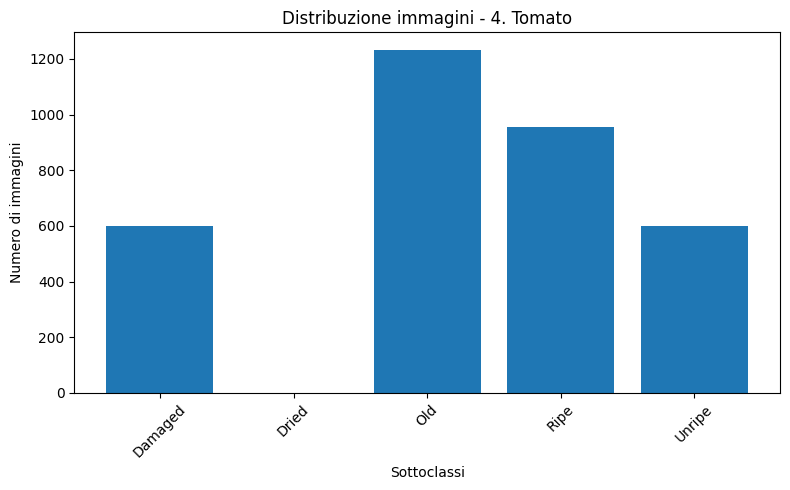

In [ ]:
final_dataset_path = '/content/image_dataset_SE/Final Dataset Balanced'

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Conta immagini per (classe principale / stato)
class_counts = defaultdict(lambda:defaultdict(int))

total_per_class = defaultdict(int)

for main_class in sorted(os.listdir(final_dataset_path)):
    main_class_path = os.path.join(final_dataset_path, main_class)
    print(f"Classe: {main_class_path}")
    if os.path.isdir(main_class_path):
        for subclass in sorted(os.listdir(main_class_path)):
            subclass_path = os.path.join(main_class_path, subclass)
            if os.path.isdir(subclass_path):
                image_files = [
                    f for f in os.listdir(subclass_path)
                    if os.path.isfile(os.path.join(subclass_path, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]


                count = len(image_files)
                class_counts[main_class][subclass] = count
                total_per_class[main_class] += count

# Stampa risultati
for main_class, subclasses in class_counts.items():
    print(f"\n📁 {main_class}")
    for subclass, count in subclasses.items():
        print(f"   └── {subclass}: {count} immagini")
    print(f"   └── \033[1mTotale:\033[0m {total_per_class[main_class]} immagini")

# Calcola totale complessivo
total_images = sum(
    count
    for subclasses in class_counts.values()
    for count in subclasses.values()
)

print(f"\n🧮 Totale immagini complessive: {total_images}")


# Plot complessivo delle classi principali
plt.figure(figsize=(8, 5))
plt.bar(total_per_class.keys(), total_per_class.values())
plt.title("Distribuzione immagini per classe principale")
plt.xlabel("Classe principale")
plt.ylabel("Numero di immagini")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




#Plot delle sottoclassi
for main_class, subclasses in class_counts.items():
    labels = list(subclasses.keys())
    counts = list(subclasses.values())

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts)
    plt.title(f"Distribuzione immagini - {main_class}")
    plt.xlabel("Sottoclassi")
    plt.ylabel("Numero di immagini")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# **Splitting in Training, Validation and Test**

Divido il dataset principale in base alle percentuali 70% / 15% / 15% ( train, val, test)

Mescolo le immagini.

Copia le immagini nelle relative cartelle:


*   dataset_split/train/...
*   dataset_split/val/...
*   dataset_split/test/...

In [ ]:
import random
import math

# Percorsi
SOURCE_DIR = "/content/image_dataset_SE/Final Dataset Balanced"
DEST_DIR = "/content/image_dataset_SE/split_dataset"

# Ratio split
SPLIT_RATIOS = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
}

# Pulisci destinazione se esiste
if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

# Funzione per dividere il dataset
def split_dataset():
    for main_class in sorted(os.listdir(SOURCE_DIR)):
        main_class_path = os.path.join(SOURCE_DIR, main_class)
        if not os.path.isdir(main_class_path):
            continue

        for subclass in sorted(os.listdir(main_class_path)):
            subclass_path = os.path.join(main_class_path, subclass)
            if not os.path.isdir(subclass_path):
                continue

            images = [f for f in os.listdir(subclass_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total = len(images)

            random.shuffle(images)

            # Calcolo split
            train_count = math.floor(SPLIT_RATIOS["train"] * total)
            val_count = math.floor(SPLIT_RATIOS["val"] * total)
            test_count = total - train_count - val_count  # il resto va in test


            split_map = {
                "train": images[:train_count],                            # primi train_count elementi
                "val": images[train_count:train_count + val_count],       # da train_count elementi fino a val_count
                "test": images[train_count + val_count:]                  # i rimanenti elementi
            }

            for split_name, split_files in split_map.items():             # Itera su ogni chiave-valore del dizionario split_map (train, val, test / lista di immagini di quel gruppo)
                dest_dir = os.path.join(DEST_DIR, split_name, main_class, subclass)
                os.makedirs(dest_dir, exist_ok=True)

                for fname in split_files:
                    src = os.path.join(subclass_path, fname)
                    dst = os.path.join(dest_dir, fname)
                    shutil.copy(src, dst)

                print(f"✅ {main_class}/{subclass} → {split_name}: {len(split_files)} immagini")

split_dataset()
print("\n✅ Dataset splittato correttamente in:", DEST_DIR)

✅ 1. Bell Pepper/Damaged → train: 420 immagini
✅ 1. Bell Pepper/Damaged → val: 90 immagini
✅ 1. Bell Pepper/Damaged → test: 90 immagini
✅ 1. Bell Pepper/Dried → train: 420 immagini
✅ 1. Bell Pepper/Dried → val: 90 immagini
✅ 1. Bell Pepper/Dried → test: 90 immagini
✅ 1. Bell Pepper/Old → train: 420 immagini
✅ 1. Bell Pepper/Old → val: 90 immagini
✅ 1. Bell Pepper/Old → test: 90 immagini
✅ 1. Bell Pepper/Ripe → train: 420 immagini
✅ 1. Bell Pepper/Ripe → val: 90 immagini
✅ 1. Bell Pepper/Ripe → test: 90 immagini
✅ 1. Bell Pepper/Unripe → train: 420 immagini
✅ 1. Bell Pepper/Unripe → val: 90 immagini
✅ 1. Bell Pepper/Unripe → test: 90 immagini
✅ 2. Chile Pepper/Damaged → train: 420 immagini
✅ 2. Chile Pepper/Damaged → val: 90 immagini
✅ 2. Chile Pepper/Damaged → test: 90 immagini
✅ 2. Chile Pepper/Dried → train: 420 immagini
✅ 2. Chile Pepper/Dried → val: 90 immagini
✅ 2. Chile Pepper/Dried → test: 90 immagini
✅ 2. Chile Pepper/Old → train: 420 immagini
✅ 2. Chile Pepper/Old → val: 90 im

**Analizing splitted dataset**

In [ ]:
DEST_DIR = "/content/image_dataset_SE/split_dataset"
for split in ["train", "val", "test"]:
    total = 0
    for root, dirs, files in os.walk(os.path.join(DEST_DIR, split)):
        total += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"📦 {split}: {total} immagini")


📦 train: 8671 immagini
📦 val: 1858 immagini
📦 test: 1860 immagini


In [ ]:
# Analizzo il test set (15% di quello principale)
final_split_dataset_path = '/content/image_dataset_SE/split_dataset/test'

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Conta immagini per (classe principale / stato)
class_counts = defaultdict(lambda:defaultdict(int))

total_per_class = defaultdict(int)

for main_class in sorted(os.listdir(final_split_dataset_path)):
    main_class_path = os.path.join(final_split_dataset_path, main_class)
    print(f"Classe: {main_class_path}")
    if os.path.isdir(main_class_path):
        for subclass in sorted(os.listdir(main_class_path)):
            subclass_path = os.path.join(main_class_path, subclass)
            if os.path.isdir(subclass_path):
                image_files = [
                    f for f in os.listdir(subclass_path)
                    if os.path.isfile(os.path.join(subclass_path, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

                count = len(image_files)
                class_counts[main_class][subclass] = count
                total_per_class[main_class] += count


# Stampa risultati
for main_class, subclasses in class_counts.items():
    print(f"\n📁 {main_class}")
    for subclass, count in subclasses.items():
        print(f"   └── {subclass}: {count} immagini")
    print(f"   └── \033[1mTotale:\033[0m {total_per_class[main_class]} immagini")

Classe: /content/image_dataset_SE/split_dataset/test/1. Bell Pepper
Classe: /content/image_dataset_SE/split_dataset/test/2. Chile Pepper
Classe: /content/image_dataset_SE/split_dataset/test/3. New Mexico Green Chile
Classe: /content/image_dataset_SE/split_dataset/test/4. Tomato

📁 1. Bell Pepper
   └── Damaged: 90 immagini
   └── Dried: 90 immagini
   └── Old: 90 immagini
   └── Ripe: 90 immagini
   └── Unripe: 90 immagini
   └── Totale: 450 immagini

📁 2. Chile Pepper
   └── Damaged: 90 immagini
   └── Dried: 90 immagini
   └── Old: 90 immagini
   └── Ripe: 90 immagini
   └── Unripe: 90 immagini
   └── Totale: 450 immagini

📁 3. New Mexico Green Chile
   └── Damaged: 90 immagini
   └── Dried: 90 immagini
   └── Old: 90 immagini
   └── Ripe: 90 immagini
   └── Unripe: 90 immagini
   └── Totale: 450 immagini

📁 4. Tomato
   └── Damaged: 90 immagini
   └── Dried: 0 immagini
   └── Old: 186 immagini
   └── Ripe: 144 immagini
   └── Unripe: 90 immagini
   └── Totale: 510 immagini


**Saving splitted dataset on my drive**

In [ ]:
# 📁 Path della cartella da zippare
FOLDER_TO_ZIP = "/content/image_dataset_SE/split_dataset"

# 📦 Nome file zip da creare
ZIP_NAME = "/content/split_dataset.zip"

# 🔁 Crea lo zip
shutil.make_archive(base_name=ZIP_NAME.replace(".zip", ""), format='zip', root_dir=FOLDER_TO_ZIP)

print("✅ Cartella compressa!")

# 📁 Percorso di destinazione su Google Drive
DRIVE_PATH = "/content/drive/MyDrive/ProgettoSE/split_dataset.zip"

# 🚀 Copia sul Drive
shutil.copy(ZIP_NAME, DRIVE_PATH)

print("✅ File zip salvato su Google Drive in:", DRIVE_PATH)


✅ Cartella compressa!
✅ File zip salvato su Google Drive in: /content/drive/MyDrive/split_dataset.zip


# **1st Stage: Vegetable Classifier**

Primo modello per distinguere il tipo di ortaggio.

Siccome il modello deve solo classificare il tipo di ortaggio e non ha bisogno di sapere il suo stato di maturazione, modifico il dataset eliminando le sottoclassi.

**Unzipping splitted dataset**

In [ ]:
import os
import shutil
import zipfile

# Percorso del file ZIP (modifica se necessario)
zip_path = "/content/drive/MyDrive/ProgettoSE/split_dataset.zip"

# Cartella di destinazione
extract_path = "/content/image_dataset_SE/split_dataset"

# Crea la directory se non esiste
os.makedirs(extract_path, exist_ok=True)

# Estrai ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Estrazione completata in:", extract_path)


✅ Estrazione completata in: /content/image_dataset_SE/split_dataset


**Creating new dataset (no subclasses)**

Vado a rimuovere le sottoclassi che indicano lo stato di maturazione

In [ ]:
# Cartella output per il dataset di classificazione tipo di ortaggio
FRUIT_TYPE_DIR = "/content/fruit_type"

# Pulisce cartella se già esiste
if os.path.exists(FRUIT_TYPE_DIR):
    shutil.rmtree(FRUIT_TYPE_DIR)

# Path dove ci sono le cartelle 1. Bell Pepper, 2. Chile Pepper, ecc.
MERGED_DATASET_TRAIN = "/content/image_dataset_SE/split_dataset/train"
MERGED_DATASET_VAL = "/content/image_dataset_SE/split_dataset/val"
MERGED_DATASET_TEST = "/content/image_dataset_SE/split_dataset/test"

# Crea fruit_type/train/<frutto>/ con immagini da tutte le sottoclassi
for fruit in os.listdir(MERGED_DATASET_TRAIN):
    fruit_path = os.path.join(MERGED_DATASET_TRAIN, fruit)
    if not os.path.isdir(fruit_path):
        continue

    dest_dir = os.path.join(FRUIT_TYPE_DIR, "train", fruit)
    os.makedirs(dest_dir, exist_ok=True)

    for state in os.listdir(fruit_path):
        state_path = os.path.join(fruit_path, state)
        if not os.path.isdir(state_path):
            continue

        for fname in os.listdir(state_path):
            src = os.path.join(state_path, fname)
            dst = os.path.join(dest_dir, f"{state}_{fname}")
            shutil.copy(src, dst)

# Crea fruit_type/val/<frutto>/ con immagini da tutte le sottoclassi
for fruit in os.listdir(MERGED_DATASET_VAL):
    fruit_path = os.path.join(MERGED_DATASET_VAL, fruit)
    if not os.path.isdir(fruit_path):
        continue

    dest_dir = os.path.join(FRUIT_TYPE_DIR, "val", fruit)
    os.makedirs(dest_dir, exist_ok=True)

    for state in os.listdir(fruit_path):
        state_path = os.path.join(fruit_path, state)
        if not os.path.isdir(state_path):
            continue

        for fname in os.listdir(state_path):
            src = os.path.join(state_path, fname)
            dst = os.path.join(dest_dir, f"{state}_{fname}")
            shutil.copy(src, dst)

# Crea fruit_type/test/<frutto>/ con immagini da tutte le sottoclassi
for fruit in os.listdir(MERGED_DATASET_TEST):
    fruit_path = os.path.join(MERGED_DATASET_TEST, fruit)
    if not os.path.isdir(fruit_path):
        continue

    dest_dir = os.path.join(FRUIT_TYPE_DIR, "test", fruit)
    os.makedirs(dest_dir, exist_ok=True)

    for state in os.listdir(fruit_path):
        state_path = os.path.join(fruit_path, state)
        if not os.path.isdir(state_path):
            continue

        for fname in os.listdir(state_path):
            src = os.path.join(state_path, fname)
            dst = os.path.join(dest_dir, f"{state}_{fname}")
            shutil.copy(src, dst)

print("✅ Dataset `fruit_type` creato correttamente.")


✅ Dataset `fruit_type` creato correttamente.


**Analizing 1st model datasets (train, val, test)**

In [ ]:
# Controllo distribuzione di immagini nei dataset splittati
from collections import defaultdict

TEST_DIR = "/content/fruit_type/train"
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

class_counts = defaultdict(int)
total_images = 0

for class_name in sorted(os.listdir(TEST_DIR)):
    class_path = os.path.join(TEST_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ])
    class_counts[class_name] = count
    total_images += count

# 📊 Risultati
print("📁 Distribuzione immagini nel train set:\n")
for cls, count in class_counts.items():
    print(f"🔹 {cls}: {count} immagini")

print(f"\n📦 Totale immagini nel train set: {total_images}")


📁 Distribuzione immagini nel train set:

🔹 1. Bell Pepper: 2100 immagini
🔹 2. Chile Pepper: 2100 immagini
🔹 3. New Mexico Green Chile: 2100 immagini
🔹 4. Tomato: 2371 immagini

📦 Totale immagini nel train set: 8671


**Creating Model**

In [ ]:
import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense

from tensorflow.keras.preprocessing import image_dataset_from_directory


BATCH_SIZE = 32
IMG_SIZE = (224, 224)  # 224x224 pixels
EPOCHS = 15

DATASET_DIR_TRAIN = "/content/fruit_type/train"
DATASET_DIR_VAL = "/content/fruit_type/val"
DATASET_DIR_TEST = "/content/fruit_type/test"

# Caricamento dati
# Crea un dataset a partire dalla directory specificata
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR_TRAIN,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
   )

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR_VAL,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR_TEST,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)


# Numero di classi
class_names = train_ds_raw.class_names  # nomi delle classi (Bell Pepper, Tomato, ecc...)
num_classes = len(class_names)
print("Classi:", class_names)


# Normalizzazione [0,1]
# converte i pixel da [0, 255] a [0.0, 1.0] → migliora la stabilità numerica.
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y))     # .map(...): applica la normalizzazione a ogni batch di immagini nel dataset.
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y))


# Migliora prestazioni I/O
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)  # cache(): memorizza il dataset in memoria dopo il primo accesso → velocizza l’addestramento.
                                                                          # shuffle(1000): mescola l’ordine delle immagini per evitare overfitting.
                                                                          # prefetch(...): carica in anticipo i batch successivi mentre il modello sta ancora elaborando il batch corrente → migliora le prestazioni.
                                                                          # AUTOTUNE: lascia che TensorFlow decida automaticamente il miglior buffer.
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 8671 files belonging to 4 classes.
Found 1858 files belonging to 4 classes.
Found 1860 files belonging to 4 classes.
Classi: ['1. Bell Pepper', '2. Chile Pepper', '3. New Mexico Green Chile', '4. Tomato']


**Training Model**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,884 (42.61 MB)

 Trainable params: 11,170,180 (42.61 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.7117 - loss: 0.7953 - val_accuracy: 0.3471 - val_loss: 5.2751
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8751 - loss: 0.3188 - val_accuracy: 0.6781 - val_loss: 0.9395
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9550 - loss: 0.1264 - val_accuracy: 0.8972 - val_loss: 0.2772
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9686 - loss: 0.0875 - val_accuracy: 0.8547 - val_loss: 0.4056
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9815 - loss: 0.0559 - val_accuracy: 0.9537 - val_loss: 0.1440
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9857 - loss: 0.0426 - val_accuracy: 0.8773 - val_loss: 0.3276
Epoch 7/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9935 - loss: 0.0251 - val_accuracy: 0.9171 - val_loss: 0.2518
Epoch 8/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9927 - loss: 0.0230 - 

✅ Modello salvato come fruit_type_classifier.h5


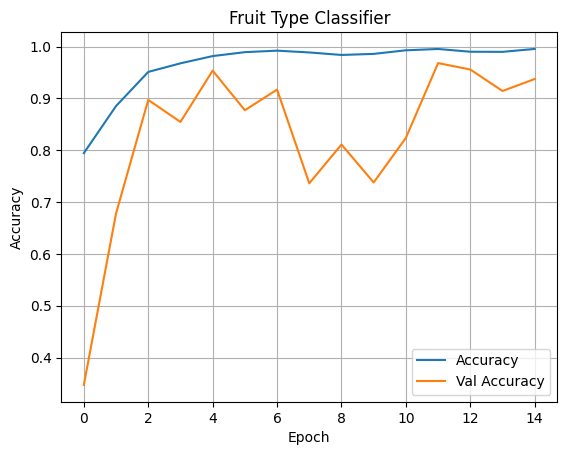

In [ ]:
# Costruzione CNN custom
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)), # 32 filtri 3x3
    layers.BatchNormalization(),    # Normalizza l'output del layer precedente
    layers.MaxPooling2D(),          # Riduce la dimensione spaziale (downsampling)

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    #layers.Conv2D(256, (3, 3), activation='relu'),
    #layers.BatchNormalization(),
    #layers.MaxPooling2D(),

    layers.Flatten(),       # da 3D (immagini) a 1D (vettore)
    layers.Dense(128, activation='relu'),  # Layer fully-connected
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')   # output finale, con una probabilità per ciascuna classe
])

# Compilazione modello
model.compile(optimizer='adam',   # ottimizzatore per immagini
              loss='sparse_categorical_crossentropy', # usata perché le label sono interi (non one-hot)
              metrics=['accuracy'])

model.summary()

# Addestramento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Salvataggio
model.save("/content/fruit_type_classifier4.h5")
print("✅ Modello salvato come fruit_type_classifier.h5")

# Plot delle metriche
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Fruit Type Classifier')
plt.grid(True)
plt.show()

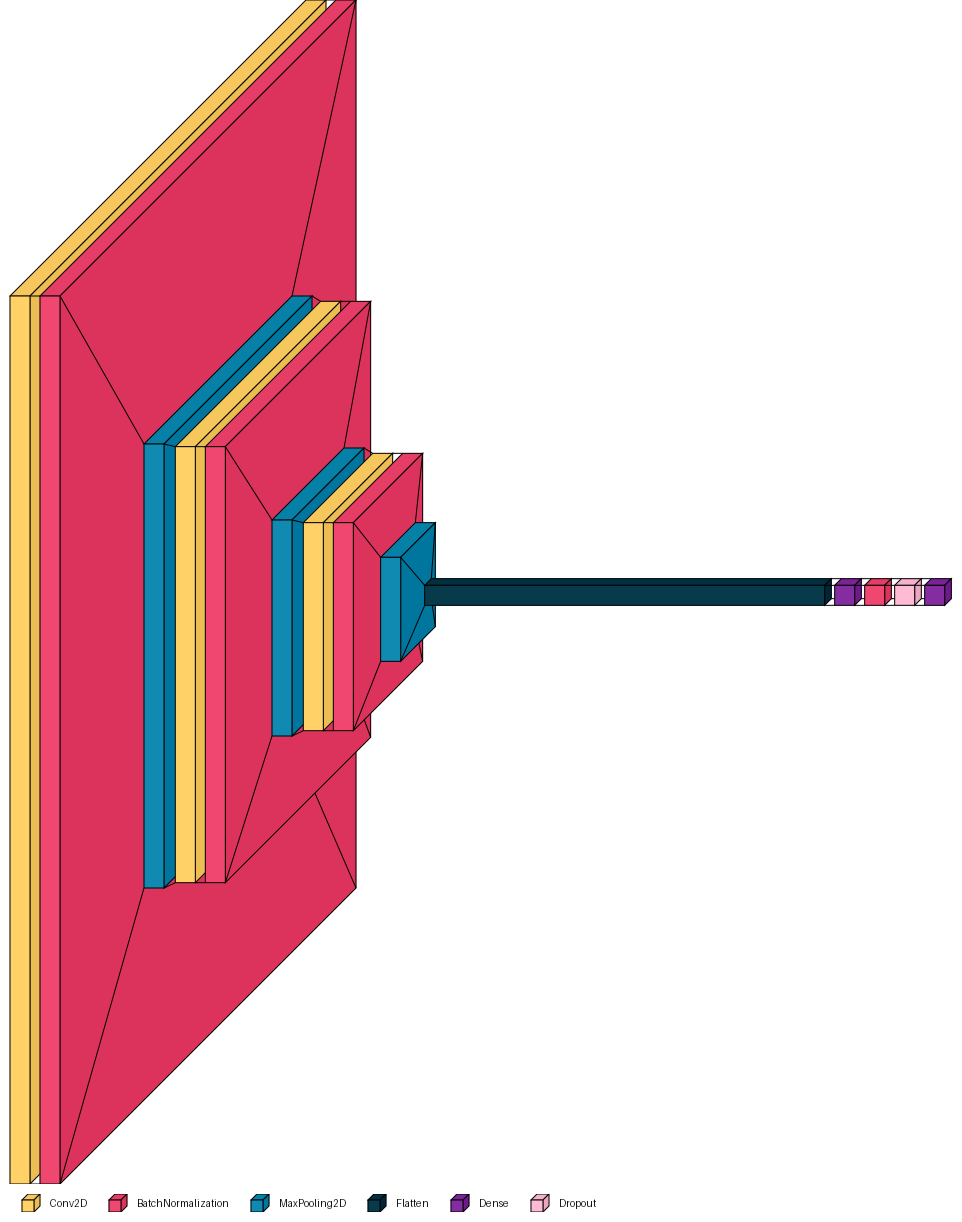

In [ ]:
!pip install visualkeras
import visualkeras

model = load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5")

visualkeras.layered_view(model, legend=True)

**Model report and confusion matrix**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━

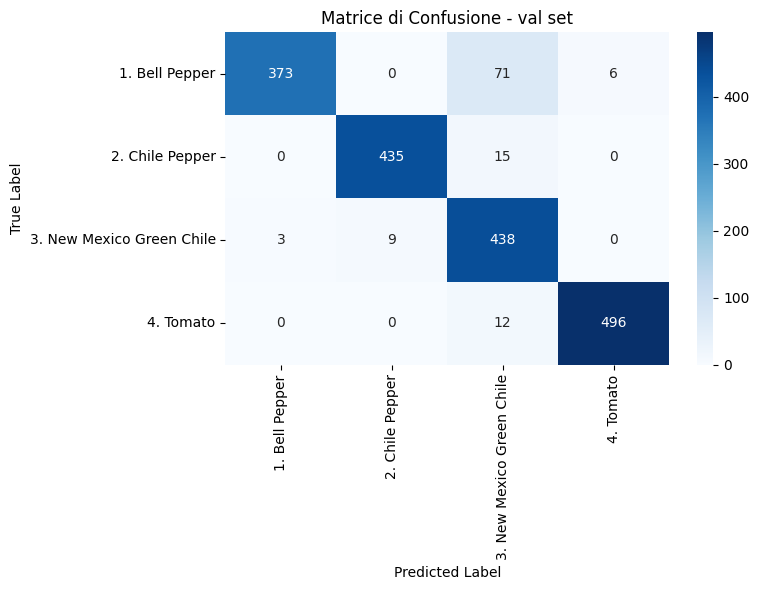

📋 Classification Report:

                           precision    recall  f1-score   support

           1. Bell Pepper       0.99      0.83      0.90       450
          2. Chile Pepper       0.98      0.97      0.97       450
3. New Mexico Green Chile       0.82      0.97      0.89       450
                4. Tomato       0.99      0.98      0.98       508

                 accuracy                           0.94      1858
                macro avg       0.94      0.94      0.94      1858
             weighted avg       0.95      0.94      0.94      1858



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5")

# Recupera i nomi delle classi
class_names = val_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# 📊 Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - val set')
plt.tight_layout()
plt.show()

# 📋 Report di classificazione
print("📋 Classification Report:\n")
print(report)


**Checking model dimension**

In [ ]:
size_bytes = os.path.getsize('/content/fruit_type_classifier4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")

📦 Il modello pesa circa 127.91 MB


In [ ]:
!cp /content/fruit_type_classifier3.h5 /content/drive/MyDrive/

**First** **Testing**

Test su una singola immagine random presa dal test set

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
✅ Immagine: Old_IMG_20220603_084402.jpg
📁 Classe reale: 2. Chile Pepper
🔍 Predizione: 2. Chile Pepper (Confidenza: 99.00%)


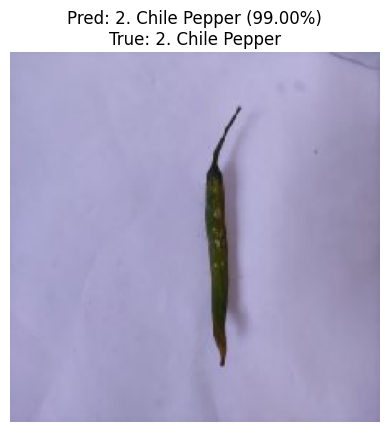

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
# Directory di test
TEST_DIR = "/content/fruit_type/test"

# Sceglie una classe e un file casuale
classes = sorted(os.listdir(TEST_DIR))
selected_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, selected_class)
selected_image = random.choice([
    f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
img_path = os.path.join(class_dir, selected_image)

# Carica e preprocessa l'immagine
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)               # Converte l'immagine in un array NumPy di forma (224, 224, 3) (RGB), i valori dei pixel sono tra 0 e 255
img_array = np.expand_dims(img_array, axis=0)     # Aggiunge una dimensione extra all’inizio, trasformandola da (224, 224, 3) → (1, 224, 224, 3)
img_array /= 255.0                                # Normalizzazione [0,1] come in addestramento

# Predizione
model = load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5")
class_names = classes                             # Se train_ds_raw.class_names non è più in RAM
pred = model.predict(img_array)                   # pred è un array NumPy di probabilità di forma (1, num_classi).
predicted_class = class_names[np.argmax(pred)]    # Trova l’indice con massima probabilità e restituisce il nome della classe corrispondente.
confidence = np.max(pred)                         # Estrae la probabilità associata alla classe predetta

# Output
print(f"✅ Immagine: {selected_image}")
print(f"📁 Classe reale: {selected_class}")
print(f"🔍 Predizione: {predicted_class} (Confidenza: {confidence:.2%})")

# Visualizza
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.2%})\nTrue: {selected_class}")
plt.axis('off')
plt.show()


**Test on all the test set and report**

Found 1860 files belonging to 4 classes.


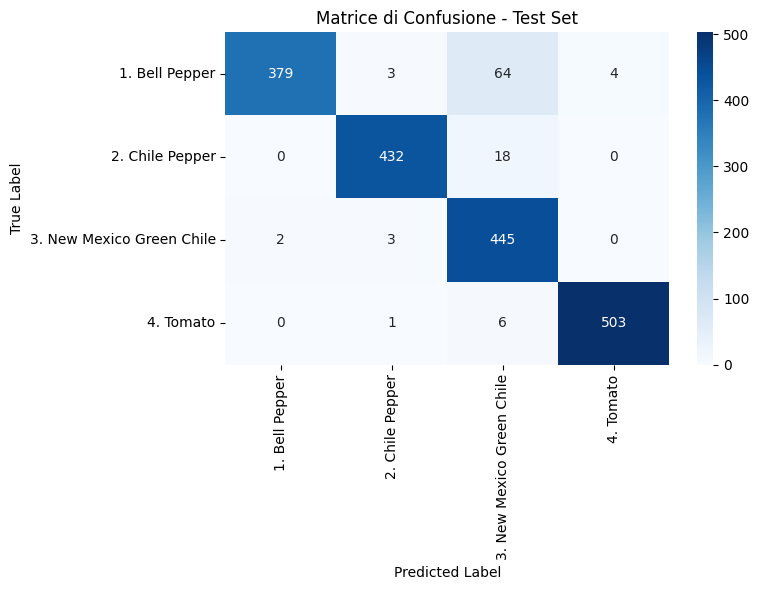

📋 Classification Report:

                           precision    recall  f1-score   support

           1. Bell Pepper       0.99      0.84      0.91       450
          2. Chile Pepper       0.98      0.96      0.97       450
3. New Mexico Green Chile       0.83      0.99      0.91       450
                4. Tomato       0.99      0.99      0.99       510

                 accuracy                           0.95      1860
                macro avg       0.95      0.94      0.94      1860
             weighted avg       0.95      0.95      0.95      1860



In [ ]:
# Carica il dataset di test
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/fruit_type/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False             # Importante per allineare predizioni con le label
)

# Normalizzazione [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y))

# Classi
class_names = test_ds_raw.class_names

# Carica il modello
model = tf.keras.models.load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5")

# Predizioni
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Matrice di Confusione - Test Set")
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report:\n")
print(report)


# **2nd Stage: one model for each fruit to determine the maturation state**

Il secondo modello serve per riconoscere lo stato di maturazione degli ortaggi.

Devo creare un modello per ogni ortaggio.

**Creating the 4 dataset (Bell Pepper, Chile Pepper, New Mexico Green Chile Pepper, Tomato)**

In [ ]:
#Creo un dataset per ogni ortaggio
import pandas as pd

# Percorso sorgente
SOURCE_DATASET = "/content/image_dataset_SE/split_dataset"
SPLITS = ['train', 'val', 'test']
MATURITY_STATES = ['Ripe', 'Unripe', 'Old', 'Dried', 'Damaged']

# Elenco cartelle dei frutti effettivamente presenti
fruit_folders = sorted(os.listdir(os.path.join(SOURCE_DATASET, 'train')))
created = []

# Crea 4 dataset: maturity_<slug>/
for fruit_folder in fruit_folders:
    slug = fruit_folder.lower().replace(' ', '_').replace('.', '').replace('__', '_')
    output_root = f"/content/maturity_{slug}"

    for split in SPLITS:
        fruit_split_path = os.path.join(SOURCE_DATASET, split, fruit_folder)
        if not os.path.exists(fruit_split_path):
            continue

        for state in MATURITY_STATES:
            state_path = os.path.join(fruit_split_path, state)
            if not os.path.isdir(state_path):
                continue

            dest_path = os.path.join(output_root, split, state)
            os.makedirs(dest_path, exist_ok=True)

            for fname in os.listdir(state_path):
                src = os.path.join(state_path, fname)
                new_name = f"{slug}_{fname}"
                dst = os.path.join(dest_path, new_name)
                shutil.copy(src, dst)
                created.append((slug, split, state))

# Conteggio immagini
summary = []
for fruit_folder in fruit_folders:
    slug = fruit_folder.lower().replace(' ', '_').replace('.', '').replace('__', '_')
    base = f"/content/maturity_{slug}"
    for split in SPLITS:
        for state in MATURITY_STATES:
            state_path = os.path.join(base, split, state)
            if os.path.exists(state_path):
                count = len([
                    f for f in os.listdir(state_path)
                    if os.path.isfile(os.path.join(state_path, f))
                ])
                summary.append({
                    'Fruit': slug,
                    'Split': split,
                    'MaturityState': state,
                    'ImageCount': count
                })

df_summary = pd.DataFrame(summary)
#import ace_tools as tools; tools.display_dataframe_to_user(name="Dataset Maturazione per Frutto", dataframe=df_summary)
from tabulate import tabulate
print(tabulate(df_summary, headers='keys', tablefmt='psql'))


+----+--------------------------+---------+-----------------+--------------+
|    | Fruit                    | Split   | MaturityState   |   ImageCount |
|----+--------------------------+---------+-----------------+--------------|
|  0 | 1_bell_pepper            | train   | Ripe            |          420 |
|  1 | 1_bell_pepper            | train   | Unripe          |          420 |
|  2 | 1_bell_pepper            | train   | Old             |          420 |
|  3 | 1_bell_pepper            | train   | Dried           |          420 |
|  4 | 1_bell_pepper            | train   | Damaged         |          420 |
|  5 | 1_bell_pepper            | val     | Ripe            |           90 |
|  6 | 1_bell_pepper            | val     | Unripe          |           90 |
|  7 | 1_bell_pepper            | val     | Old             |           90 |
|  8 | 1_bell_pepper            | val     | Dried           |           90 |
|  9 | 1_bell_pepper            | val     | Damaged         |           90 |

**Tomato Model**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

# Parametri
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 10
MATURITY_TOMATO_DIR = "/content/maturity_4_tomato"

# Caricamento dati
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_TOMATO_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_TOMATO_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_TOMATO_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Classi
class_names = train_ds_raw.class_names
num_classes = len(class_names)


# Normalizzazione [0,1]
# converte i pixel da [0, 255] a [0.0, 1.0] → migliora la stabilità numerica.
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y))     # .map(...): applica la normalizzazione a ogni batch di immagini nel dataset.
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y))


# Migliora prestazioni I/O
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)  # cache(): memorizza il dataset in memoria dopo il primo accesso → velocizza l’addestramento.
                                                                          # shuffle(1000): mescola l’ordine delle immagini per evitare overfitting.
                                                                          # prefetch(...): carica in anticipo i batch successivi mentre il modello sta ancora elaborando il batch corrente → migliora le prestazioni.
                                                                          # AUTOTUNE: lascia che TensorFlow decida automaticamente il miglior buffer.
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2371 files belonging to 5 classes.
Found 508 files belonging to 5 classes.
Found 510 files belonging to 5 classes.


**Training**

Found 2371 files belonging to 5 classes.
Found 508 files belonging to 5 classes.
Found 510 files belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.4732 - loss: 1.2925 - val_accuracy: 0.8012 - val_loss: 0.4874
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7771 - loss: 0.4975 - val_accuracy: 0.8937 - val_loss: 0.3249
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8369 - loss: 0.4053 - val_accuracy: 0.8898 - val_loss: 0.3022
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8784 - loss: 0.3121 - val_accuracy: 0.9134 - val_loss: 0.2571
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8753 - loss: 0.3077 - val_accuracy: 0.9193 - val_loss: 0.2092
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8651 - loss: 0.3521 - val_accuracy: 0.9272 - val_loss: 0.1758
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9095 - loss: 0.2279 - val_accuracy: 0.9173 - val_loss: 0.1896
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9432 - loss: 0.1533 - val_accuracy: 0.8760 - val_loss: 

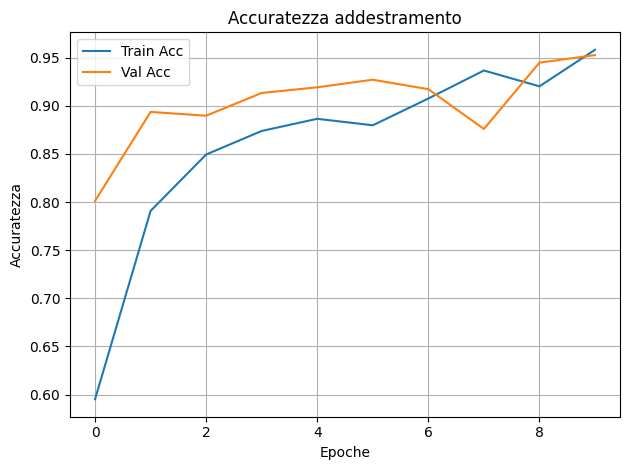

✅ Modello salvato come maturity_tomato.h5


In [ ]:
# CNN custom
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(*IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compila modello
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestramento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuratezza addestramento')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

model.save("/content/maturity_tomato.h5")
print("✅ Modello salvato come maturity_tomato.h5")


**Report**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_tomato4.h5")

# Recupera i nomi delle classi
class_names = val_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
#cm = confusion_matrix(y_true, y_pred)
# La classe Tomato non contiene immagini nella sottoclasse Dried
# il report è corretto ma la matrice di confusione no, perchè la sottoclasse Dried è presente nei y_pred, ma non nei y_true
# Se una classe (es. Dried) non è mai presente in y_true, la matrice di confusione non può visualizzarla nella riga corrispondente (perché non ha alcuna verità di base da confrontare).
# La colonna Dried potrebbe invece essere popolata, se il modello la predice.
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    zero_division=0  # evita errori per classi non presenti
)

# Stampa matrice
#plt.figure(figsize=(8, 6))
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#            xticklabels=class_names, yticklabels=class_names)
#plt.xlabel('Predicted Label')
#plt.ylabel('True Label')
#plt.title('Matrice di Confusione - Tomato val set')
#plt.tight_layout()
#plt.show()

# Report di classificazione
print("📋 Classification Report on val set:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
📋 Classification Report:

              precision    recall  f1-score   support

     Damaged       0.96      0.91      0.94        90
       Dried       0.00      0.00      0.00         0
         Old       0.95      0.94      0.94       185
        Ripe       0.93      0.97      0.95       143
      Unripe       1.00      1.00      1.00        90

    accuracy                           0.95       5

In [ ]:
model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_tomato4.h5")

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_4_tomato/test",
    image_size=(224, 224),
    batch_size=32
)

# Normalizzazione [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y))

# Recupera i nomi delle classi
class_names = test_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
#cm = confusion_matrix(y_true, y_pred)
# La classe Tomato non contiene immagini nella sottoclasse Dried
# il report è corretto ma la matrice di confusione no, perchè la sottoclasse Dried è presente nei y_pred, ma non nei y_true
# Se una classe (es. Dried) non è mai presente in y_true, la matrice di confusione non può visualizzarla nella riga corrispondente (perché non ha alcuna verità di base da confrontare).
# La colonna Dried potrebbe invece essere popolata, se il modello la predice.
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    zero_division=0  # evita errori per classi non presenti
)


# Report di classificazione
print("📋 Classification Report on test set:\n")
print(report)

Found 510 files belonging to 5 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
📋 Classification Report on test set:

              precision    recall  f1-score   support

     Damaged       0.92      0.89      0.90        90
       Dried       0.00      0.00      0.00         0
         Old       0.92      0.92      0.92       186
        Ripe       0.93      0.96      0.95       144
      Unripe       1.00      1.00      1.00  

**Tomato Model Accuracy on val and test set**

In [ ]:
# Normalizzazione e prefetch per il test set
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_4_tomato/val",
    image_size=(224, 224),
    batch_size=32
)

# Classi
class_names = val_ds.class_names

# Applica normalizzazione
normalization_layer = layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



# Valutazione finale
loss, acc = model.evaluate(val_ds)
print(f"🎯 Accuratezza sul val set: {acc:.2%}")

Found 508 files belonging to 5 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9512 - loss: 0.1330
🎯 Accuratezza sul val set: 95.28%


In [ ]:
# Normalizzazione e prefetch per il test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_4_tomato/test",
    image_size=(224, 224),
    batch_size=32
)

# Classi
class_names = test_ds.class_names

# Applica normalizzazione
normalization_layer = layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



# Valutazione finale
loss, acc = model.evaluate(test_ds)
print(f"🎯 Accuratezza sul test set: {acc:.2%}")


Found 510 files belonging to 5 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9315 - loss: 0.1895
🎯 Accuratezza sul test set: 93.92%


**Test on a random image from the tomato test set**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
✅ Immagine: 4_tomato_IMG_20220612_151123_aug262.jpg
📁 Classe reale: Damaged
🔍 Predizione: Damaged (Confidenza: 100.00%)


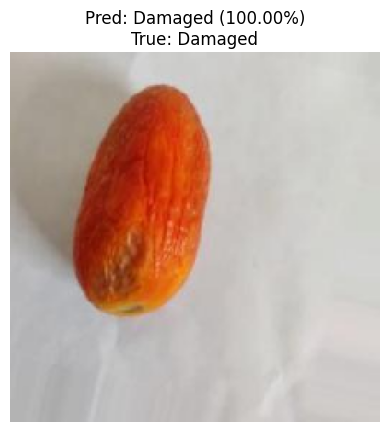

In [ ]:
# Test su un immagine random presa dal test set

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
# Directory di test
TEST_DIR = "/content/maturity_4_tomato/test"

# Scegli una classe e un file casuale
classes = sorted(os.listdir(TEST_DIR))
selected_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, selected_class)
selected_image = random.choice([
    f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
img_path = os.path.join(class_dir, selected_image)

# Carica e preprocessa l'immagine
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalizzazione [0,1]

# Predizione
model = load_model("/content/maturity_tomato.h5")
class_names = classes  # Assumiamo che train_ds_raw.class_names non sia più in RAM
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Output
print(f"✅ Immagine: {selected_image}")
print(f"📁 Classe reale: {selected_class}")
print(f"🔍 Predizione: {predicted_class} (Confidenza: {confidence:.2%})")

# Visualizza
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.2%})\nTrue: {selected_class}")
plt.axis('off')
plt.show()

Test su un immagine custom salvata in una directory

In [ ]:
# Path dell’immagine di test
img_path = "/content/drive/MyDrive/download.jpg"  # <-- cambia questo

# Carica l’immagine e ridimensiona
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 224, 224, 3)
img_array /= 255.0  # normalizzazione [0,1]

# Predizione
pred = model.predict(img_array)
pred_class_idx = np.argmax(pred)
confidence = np.max(pred)

# Classi
print(f"🔍 Predetto: {class_names[pred_class_idx]} (confidenza: {confidence:.2%})")

# Mostra immagine
plt.imshow(img)
plt.title(f"Predetto: {class_names[pred_class_idx]}")
plt.axis('off')
plt.show()


**Bell Pepper Model**

In [ ]:
# Parametri
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 18
MATURITY_BELLPEPPER_DIR = "/content/maturity_1_bell_pepper"

# Caricamento dati
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_BELLPEPPER_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_BELLPEPPER_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_BELLPEPPER_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Classi
class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Normalizzazione
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2100 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Found 450 files belonging to 5 classes.


In [ ]:
# CNN custom
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compila modello
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestramento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuratezza addestramento')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

model.save("/content/maturity_bellpepper.h5")  # 🔁 cambia nome per ogni frutto
print("✅ Modello salvato come bellpepper.h5")

**Report**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


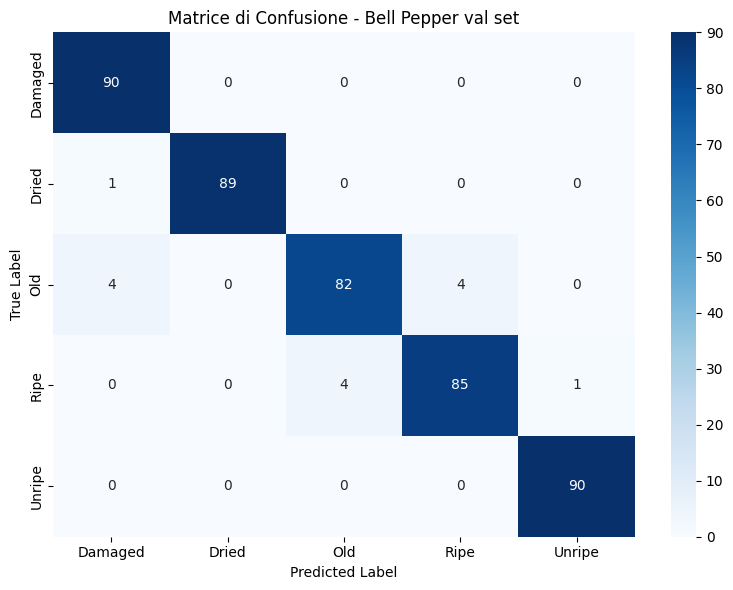

📋 Classification Report on val set:

              precision    recall  f1-score   support

     Damaged       0.95      1.00      0.97        90
       Dried       1.00      0.99      0.99        90
         Old       0.95      0.91      0.93        90
        Ripe       0.96      0.94      0.95        90
      Unripe       0.99      1.00      0.99        90

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.h5")

# Recupera i nomi delle classi
class_names = val_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - Bell Pepper val set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on val set:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


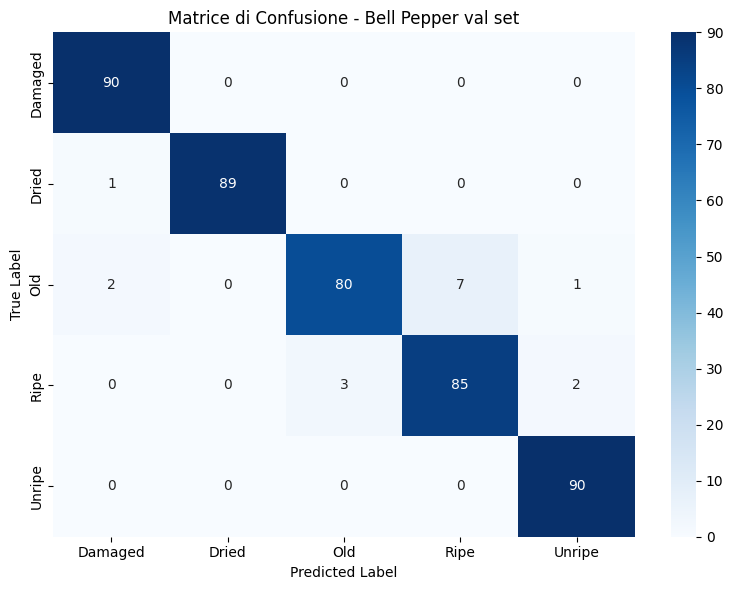

📋 Classification Report on test set:

              precision    recall  f1-score   support

     Damaged       0.97      1.00      0.98        90
       Dried       1.00      0.99      0.99        90
         Old       0.96      0.89      0.92        90
        Ripe       0.92      0.94      0.93        90
      Unripe       0.97      1.00      0.98        90

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.h5")

# Recupera i nomi delle classi
class_names = test_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - Bell Pepper val set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on test set:\n")
print(report)

**Bell Pepper Model Accuracy**

In [ ]:
# Carico il dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_1_bell_pepper/test",
    image_size=(224, 224),
    batch_size=32
)

# Classi
class_names = val_ds.class_names

# Applica normalizzazione
normalization_layer = layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



# Valutazione finale
loss, acc = model.evaluate(val_ds)
print(f"🎯 Accuratezza sul val set: {acc:.2%}")

Found 450 files belonging to 5 classes.
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9662 - loss: 0.1422
🎯 Accuratezza sul val set: 96.44%


**Test on a random image from the bellpepper test set**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
✅ Immagine: 1_bell_pepper_IMG_20220606_095241.jpg
📁 Classe reale: Old
🔍 Predizione: Old (Confidenza: 89.27%)


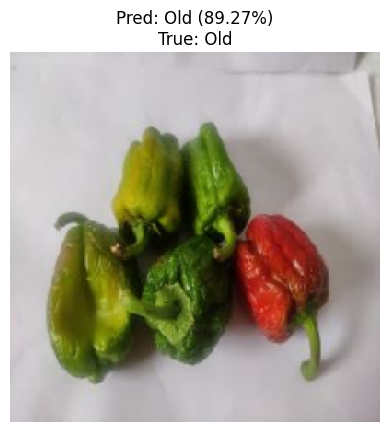

In [ ]:
#Test su un immagine random presa dal test set

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
# Directory di test
TEST_DIR = "/content/maturity_1_bell_pepper/test"

# Scegli una classe e un file casuale
classes = sorted(os.listdir(TEST_DIR))
selected_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, selected_class)
selected_image = random.choice([
    f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
img_path = os.path.join(class_dir, selected_image)

# Carica e preprocessa l'immagine
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalizzazione [0,1]

# Predizione
model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.h5")
class_names = classes  # Assumiamo che train_ds_raw.class_names non sia più in RAM
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Output
print(f"✅ Immagine: {selected_image}")
print(f"📁 Classe reale: {selected_class}")
print(f"🔍 Predizione: {predicted_class} (Confidenza: {confidence:.2%})")

# Visualizza
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.2%})\nTrue: {selected_class}")
plt.axis('off')
plt.show()


**Chile Pepper Model**

In [ ]:
# Parametri
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 10
MATURITY_CHILEPEPPER_DIR = "/content/maturity_2_chile_pepper"

# Caricamento dati
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_CHILEPEPPER_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_CHILEPEPPER_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_CHILEPEPPER_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Classi
class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Normalizzazione
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2100 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Found 450 files belonging to 5 classes.


Found 2100 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.4558 - loss: 1.7753 - val_accuracy: 0.8067 - val_loss: 0.5446
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7815 - loss: 0.5287 - val_accuracy: 0.9044 - val_loss: 0.3418
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8667 - loss: 0.3686 - val_accuracy: 0.9156 - val_loss: 0.2309
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8776 - loss: 0.3498 - val_accuracy: 0.8756 - val_loss: 0.3241
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8767 - loss: 0.3032 - val_accuracy: 0.8978 - val_loss: 0.2339
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9284 - loss: 0.1772 - val_accuracy: 0.9289 - val_loss: 0.1781
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8740 - loss: 0.3394 - val_accuracy: 0.9178 - val_lo

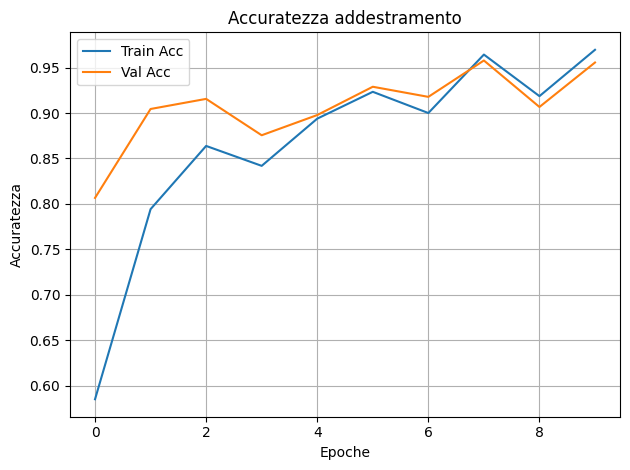

✅ Modello salvato come chilepepper.h5


In [ ]:
# CNN custom
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(*IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compila modello
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestramento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuratezza addestramento')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


model.save("/content/maturity_chilepepper.h5")  # 🔁 cambia nome per ogni frutto
print("✅ Modello salvato come chilepepper.h5")

**Report**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


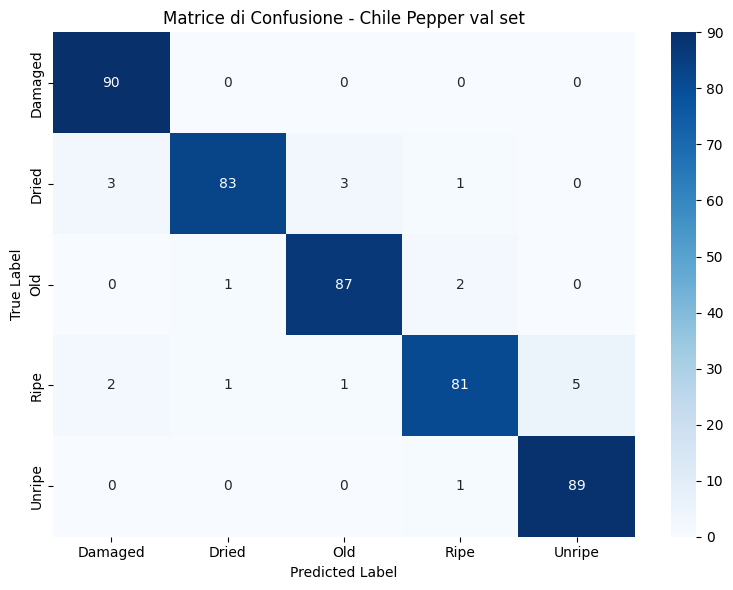

📋 Classification Report on val set:

              precision    recall  f1-score   support

     Damaged       0.95      1.00      0.97        90
       Dried       0.98      0.92      0.95        90
         Old       0.96      0.97      0.96        90
        Ripe       0.95      0.90      0.93        90
      Unripe       0.95      0.99      0.97        90

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_chilepepper4.h5")

# Recupera i nomi delle classi
class_names = val_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - Chile Pepper val set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on val set:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 943ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


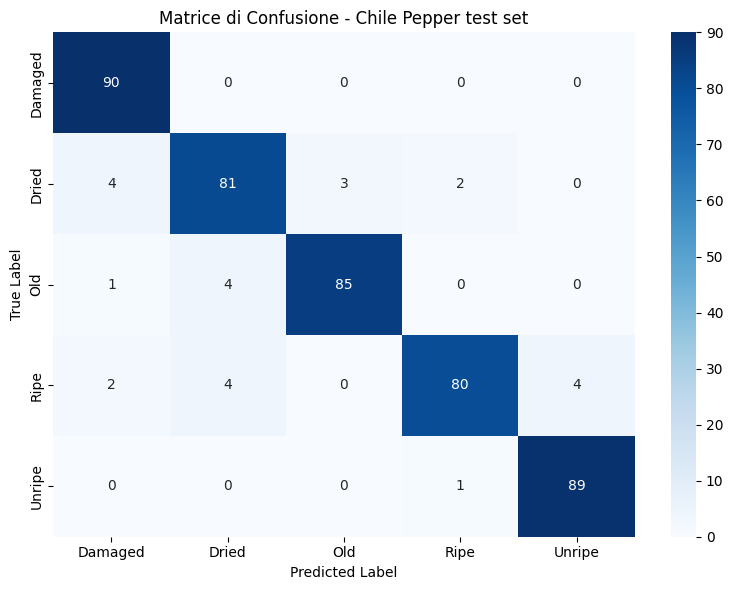

📋 Classification Report on test set:

              precision    recall  f1-score   support

     Damaged       0.93      1.00      0.96        90
       Dried       0.91      0.90      0.91        90
         Old       0.97      0.94      0.96        90
        Ripe       0.96      0.89      0.92        90
      Unripe       0.96      0.99      0.97        90

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_chilepepper4.h5")

# Recupera i nomi delle classi
class_names = test_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - Chile Pepper test set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on test set:\n")
print(report)

**Chile Pepper model Accuracy**

In [ ]:
# Normalizzazione e prefetch per il val set
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_2_chile_pepper/test",
    image_size=(224, 224),
    batch_size=32
)

# 🔍 Classi
class_names = val_ds.class_names

# Applica normalizzazione
normalization_layer = layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



# Valutazione finale
loss, acc = model.evaluate(val_ds)
print(f"🎯 Accuratezza sul val set: {acc:.2%}")

Found 450 files belonging to 5 classes.
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9384 - loss: 0.2194
🎯 Accuratezza sul val set: 94.44%


**Test on a random image from the chilepepper test set**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
✅ Immagine: 2_chile_pepper_IMG_20220601_094420_aug127.jpg
📁 Classe reale: Ripe
🔍 Predizione: Ripe (Confidenza: 79.07%)


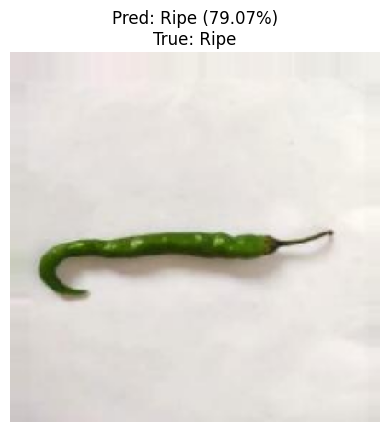

In [ ]:
#Test su un immagine random presa dal test set

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
# 📁 Directory di test
TEST_DIR = "/content/maturity_2_chile_pepper/test"

# 🔀 Scegli una classe e un file casuale
classes = sorted(os.listdir(TEST_DIR))
selected_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, selected_class)
selected_image = random.choice([
    f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
img_path = os.path.join(class_dir, selected_image)

# 📷 Carica e preprocessa l'immagine
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalizzazione [0,1]

# 🔮 Predizione
model = load_model("/content/maturity_chilepepper.h5")
class_names = classes  # Assumiamo che train_ds_raw.class_names non sia più in RAM
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# 📊 Output
print(f"✅ Immagine: {selected_image}")
print(f"📁 Classe reale: {selected_class}")
print(f"🔍 Predizione: {predicted_class} (Confidenza: {confidence:.2%})")

# 🖼️ Visualizza
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.2%})\nTrue: {selected_class}")
plt.axis('off')
plt.show()


**New Mexico Green Chile Model**

In [ ]:
# Parametri
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 13
MATURITY_NEWMEX_DIR = "/content/maturity_3_new_mexico_green_chile"

# Caricamento dati
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_NEWMEX_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_NEWMEX_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MATURITY_NEWMEX_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Classi
class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Normalizzazione
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2100 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Found 450 files belonging to 5 classes.


Found 2100 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Found 450 files belonging to 5 classes.
Epoch 1/13


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.6377 - loss: 1.1702 - val_accuracy: 0.2000 - val_loss: 1.9487
Epoch 2/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8402 - loss: 0.4309 - val_accuracy: 0.4022 - val_loss: 1.7446
Epoch 3/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8807 - loss: 0.3025 - val_accuracy: 0.4067 - val_loss: 1.3921
Epoch 4/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9287 - loss: 0.2034 - val_accuracy: 0.3933 - val_loss: 2.7584
Epoch 5/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9624 - loss: 0.1168 - val_accuracy: 0.4378 - val_loss: 1.6416
Epoch 6/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9684 - loss: 0.0963 - val_accuracy: 0.8178 - val_loss: 0.5005
Epoch 7/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9825 - loss: 0.0575 - val_accuracy: 0.5089 - val_loss: 1.5208
Epoch 8/13
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9905 - loss: 0.0408 - val_accuracy: 0.7844 - val_loss: 

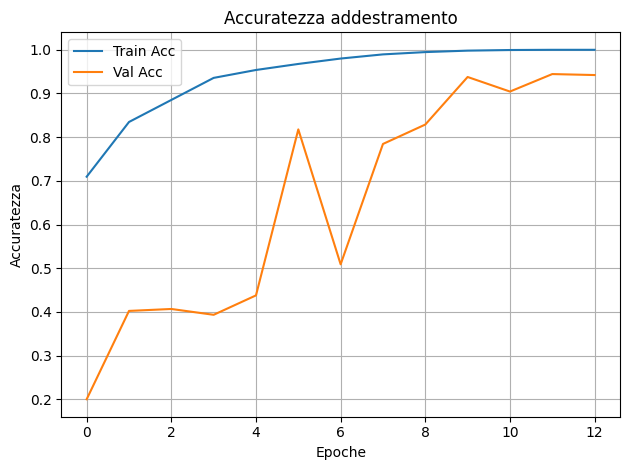

✅ Modello salvato come newmexchilepepper.h5


In [ ]:
# CNN custom
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compila modello
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestramento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuratezza addestramento')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


model.save("/content/maturity_newmexchilepepper.h5")  # 🔁 cambia nome per ogni frutto
print("✅ Modello salvato come newmexchilepepper.h5")

**Report**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


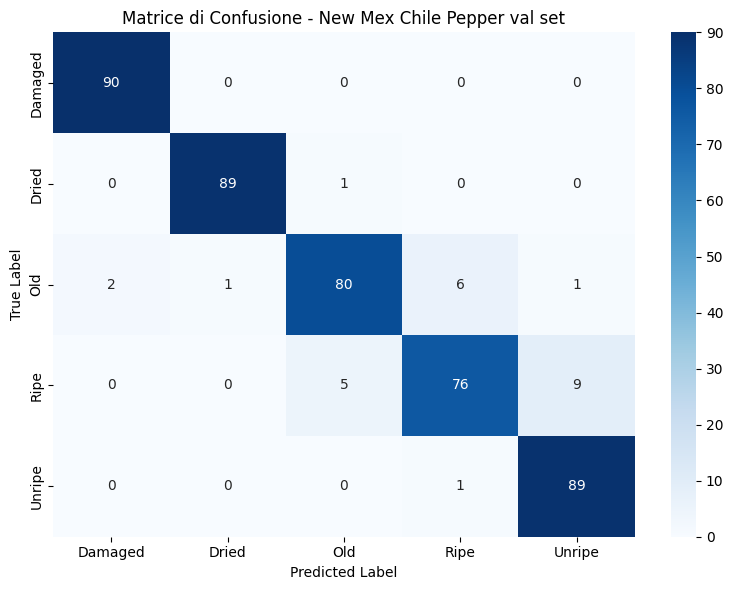

📋 Classification Report on val set:

              precision    recall  f1-score   support

     Damaged       0.98      1.00      0.99        90
       Dried       0.99      0.99      0.99        90
         Old       0.93      0.89      0.91        90
        Ripe       0.92      0.84      0.88        90
      Unripe       0.90      0.99      0.94        90

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_newmexchilepepper4.h5")

# Recupera i nomi delle classi
class_names = val_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - New Mex Chile Pepper val set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on val set:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step


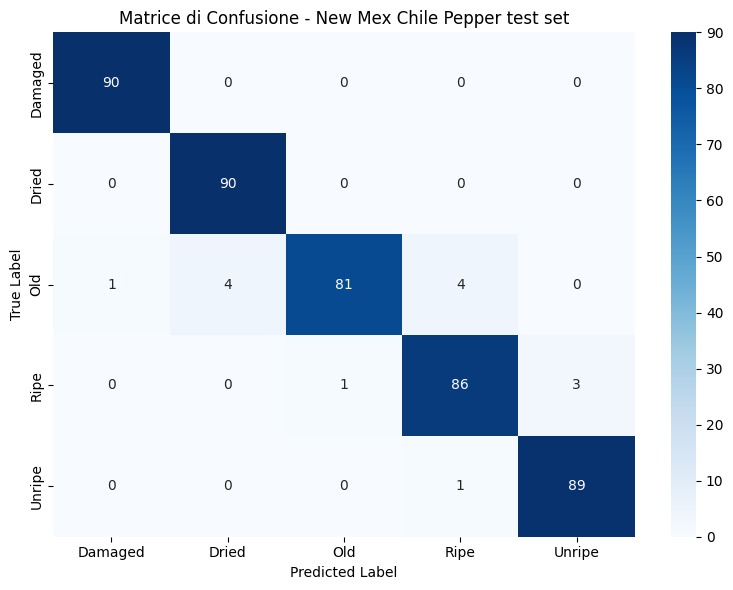

📋 Classification Report on test set:

              precision    recall  f1-score   support

     Damaged       0.99      1.00      0.99        90
       Dried       0.96      1.00      0.98        90
         Old       0.99      0.90      0.94        90
        Ripe       0.95      0.96      0.95        90
      Unripe       0.97      0.99      0.98        90

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_newmexchilepepper4.h5")

# Recupera i nomi delle classi
class_names = test_ds_raw.class_names

# Estrai immagini e label reali
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Stampa matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matrice di Confusione - New Mex Chile Pepper test set')
plt.tight_layout()
plt.show()

# Report di classificazione
print("📋 Classification Report on test set:\n")
print(report)

**New Mex Model Accuracy**

In [ ]:
# Normalizzazione e prefetch per il val set
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/maturity_3_new_mexico_green_chile/test", # cambia /val con /test per ottenere accuracy sul test set
    image_size=(224, 224),
    batch_size=32
)

# 🔍 Classi
class_names = val_ds.class_names

# Applica normalizzazione
normalization_layer = layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



# Valutazione finale
loss, acc = model.evaluate(val_ds)
print(f"🎯 Accuratezza sul val set: {acc:.2%}")

Found 450 files belonging to 5 classes.
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9588 - loss: 0.1331
🎯 Accuratezza sul val set: 96.89%


**Test on a random image from the newmex test set**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
✅ Immagine: 3_new_mexico_green_chile_IMG_20220604_093415_aug209.jpg
📁 Classe reale: Old
🔍 Predizione: Old (Confidenza: 70.11%)


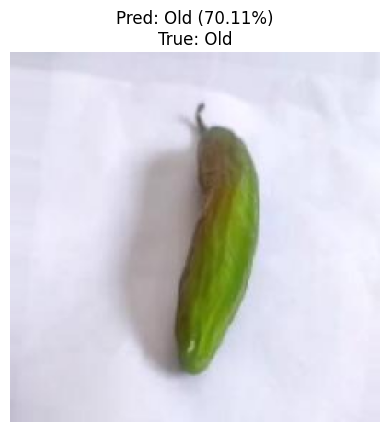

In [ ]:
#Test su un immagine random presa dal test set

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random
# Directory di test
TEST_DIR = "/content/maturity_3_new_mexico_green_chile/test"

# Scegli una classe e un file casuale
classes = sorted(os.listdir(TEST_DIR))
selected_class = random.choice(classes)
class_dir = os.path.join(TEST_DIR, selected_class)
selected_image = random.choice([
    f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
img_path = os.path.join(class_dir, selected_image)

# Carica e preprocessa l'immagine
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalizzazione [0,1]

# Predizione
model = load_model("/content/maturity_newmexchilepepper.h5")
class_names = classes  # Assumiamo che train_ds_raw.class_names non sia più in RAM
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Output
print(f"✅ Immagine: {selected_image}")
print(f"📁 Classe reale: {selected_class}")
print(f"🔍 Predizione: {predicted_class} (Confidenza: {confidence:.2%})")

# Visualizza
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.2%})\nTrue: {selected_class}")
plt.axis('off')
plt.show()


# **Final Inference**

Prendo i modelli salvati sul workspace o dal drive e faccio inferenza, classificando il tipo di ortaggio e il suo stato di maturazione.

In [ ]:
!cp /content/maturity_tomato4.h5 /content/drive/MyDrive/
!cp /content/maturity_bellpepper4.h5 /content/drive/MyDrive/
!cp /content/maturity_chilepepper4.h5 /content/drive/MyDrive/
!cp /content/maturity_newmexchilepepper4.h5 /content/drive/MyDrive/

In [ ]:
size_bytes = os.path.getsize('/content/fruit_type_classifier4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_bellpepper4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_chilepepper4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_tomato4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_newmexchilepepper4.h5')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")

📦 Il modello pesa circa 127.91 MB
📦 Il modello pesa circa 127.92 MB
📦 Il modello pesa circa 127.87 MB
📦 Il modello pesa circa 127.87 MB
📦 Il modello pesa circa 127.92 MB


**Loading models**

In [ ]:
from tensorflow.keras.models import load_model

# Carica il modello del tipo di frutto
model_fruit = load_model("/content/fruit_type_classifier4.h5", compile=False)

# Carica i 4 modelli
model_tomato = load_model("/content/maturity_tomato4.h5", compile=False)
model_bell_pepper = load_model("/content/maturity_bellpepper4.h5", compile=False)
model_chile_pepper = load_model("/content/maturity_chilepepper4.h5", compile=False)
model_newmex = load_model("/content/maturity_newmexchilepepper4.h5", compile=False)

In [ ]:
################## SE VOGLIO CARICARE DAL DRIVE#################
from tensorflow.keras.models import load_model

# Carica il modello del tipo di frutto
model_fruit = load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5", compile=False)

# Carica i 4 modelli
model_tomato = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_tomato4.h5", compile=False)
model_bell_pepper = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.h5", compile=False)
model_chile_pepper = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_chilepepper4.h5", compile=False)
model_newmex = load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_newmexchilepepper4.h5", compile=False)

**Inference on a random image took from all the test set**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
✅ Vero: 2. Chile Pepper | ✅ Vero: Ripe
🔮 Pred: 2. Chile Pepper | 🔮 Pred: Ripe


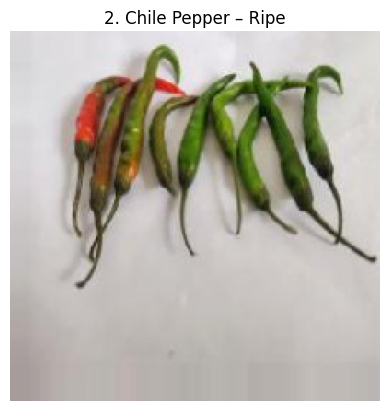

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Parametri
IMG_SIZE = (224, 224)
TEST_ROOT = "/content/image_dataset_SE/split_dataset/test"

# Carica modelli
model_fruit = load_model("/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.h5")
model_maturity = {
    "1. Bell Pepper": load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.h5"),
    "2. Chile Pepper": load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_chilepepper4.h5"),
    "3. New Mexico Green Chile": load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_newmexchilepepper4.h5"),
    "4. Tomato": load_model("/content/drive/MyDrive/ProgettoSE/models/maturity_tomato4.h5")
}

# Classi
fruit_class_names = list(model_maturity.keys())
maturity_classes = ['Damaged', 'Dried', 'Old', 'Ripe', 'Unripe']

# Scegli un'immagine random dal test set
all_paths = []
for fruit in os.listdir(TEST_ROOT):
    fruit_path = os.path.join(TEST_ROOT, fruit)
    for maturity in os.listdir(fruit_path):
        maturity_path = os.path.join(fruit_path, maturity)
        for fname in os.listdir(maturity_path):
            all_paths.append((fruit, maturity, os.path.join(maturity_path, fname)))

            selected_fruit, selected_maturity, img_path = random.choice(all_paths)

# Carica immagine
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

# Predizione frutto
fruit_pred_idx = np.argmax(model_fruit.predict(img_input))
fruit_pred = fruit_class_names[fruit_pred_idx]

# Predizione maturazione con modello corretto
maturity_model = model_maturity[fruit_pred]
maturity_pred_idx = np.argmax(maturity_model.predict(img_input))
maturity_pred = maturity_classes[maturity_pred_idx]

# Risultati
print(f"✅ Vero: {selected_fruit} | ✅ Vero: {selected_maturity}")
print(f"🔮 Pred: {fruit_pred} | 🔮 Pred: {maturity_pred}")

# Mostra immagine
plt.imshow(img)
plt.title(f"{fruit_pred} – {maturity_pred}")
plt.axis('off')
plt.show()

**Inference on a single image saved in the drive**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
🔮 Frutto predetto: 1. Bell Pepper
🔮 Stato maturazione: Dried


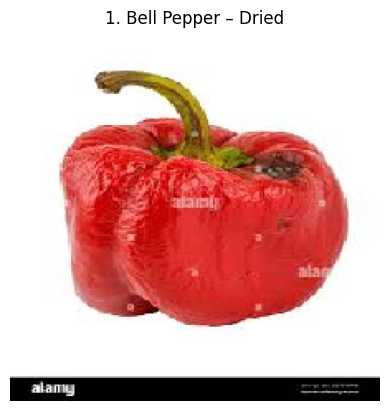

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Parametri
IMG_SIZE = (224, 224)
IMG_PATH = "/content/drive/MyDrive/download (1).jpg"

# Carica modelli
model_fruit = load_model("/content/fruit_type_classifier4.h5")
model_maturity = {
    "1. Bell Pepper": load_model("/content/maturity_bellpepper4.h5"),
    "2. Chile Pepper": load_model("/content/maturity_chilepepper4.h5"),
    "3. New Mexico Green Chile": load_model("/content/maturity_newmexchilepepper4.h5"),
    "4. Tomato": load_model("/content/maturity_tomato4.h5")
}

# Classi
fruit_class_names = list(model_maturity.keys())
maturity_classes = ['Damaged', 'Dried', 'Old', 'Ripe', 'Unripe']

# Carica immagine
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

# Predizione frutto
fruit_pred_idx = np.argmax(model_fruit.predict(img_input))
fruit_pred = fruit_class_names[fruit_pred_idx]

# Predizione maturazione
maturity_model = model_maturity[fruit_pred]
maturity_pred_idx = np.argmax(maturity_model.predict(img_input))
maturity_pred = maturity_classes[maturity_pred_idx]

# Risultati
print(f"🔮 Frutto predetto: {fruit_pred}")
print(f"🔮 Stato maturazione: {maturity_pred}")

# Mostra immagine
plt.imshow(img)
plt.title(f"{fruit_pred} – {maturity_pred}")
plt.axis('off')
plt.show()


# **Converting in TFlite**

In [ ]:
# Parametri
model_path = "/content/maturity_tomato4.h5"
tflite_path = "/content/maturity_tomato4.tflite"

# Caricamento del modello
model = tf.keras.models.load_model(model_path)

# Conversione con quantizzazione float16
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]            # ottimizzazione automatica
converter.target_spec.supported_types = [tf.float16]            # abilita la quantizzazione float16
tflite_model = converter.convert()                              # conversione

# Salva
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Salvato: {tflite_path}")

model_path = "/content/maturity_bellpepper4.h5"
tflite_path = "/content/maturity_bellpepper4.tflite"

# Conversione con quantizzazione float16
model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Salva
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Salvato: {tflite_path}")

model_path = "/content/maturity_chilepepper4.h5"
tflite_path = "/content/maturity_chilepepper4.tflite"

# Conversione con quantizzazione float16
model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Salva
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Salvato: {tflite_path}")

model_path = "/content/maturity_newmexchilepepper4.h5"
tflite_path = "/content/maturity_newmexchilepepper4.tflite"

# Conversione con quantizzazione float16
model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Salva
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Salvato: {tflite_path}")

model_path = "/content/fruit_type_classifier4.h5"
tflite_path = "/content/fruit_type_classifier4.tflite"

# Conversione con quantizzazione float16
model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Salva
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Salvato: {tflite_path}")

Saved artifact at '/tmp/tmp4l2ltknh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132287137788944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287137791824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287137789328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287137789136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127882832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127883600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127883024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127882064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127884752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127885712: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Salvato: /con

Saved artifact at '/tmp/tmpumqrgz9o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132287127888976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127895504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074255312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074255888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127895696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074256272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074257040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074258192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074256

Saved artifact at '/tmp/tmpe2ovsjpv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_12')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132287074270480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074268752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074268944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074267984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074268176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074266640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074261456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074266832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074268560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287074267600: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Salvato: /co

Saved artifact at '/tmp/tmpz34x_n97'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_15')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132287127885328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132287127884944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872749264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872749840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872748880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872748304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872750224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872751568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872750992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872752144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132286872750

Saved artifact at '/tmp/tmp25k7n92b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132285700771088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700780304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700781648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700779728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700781456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700780496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700779344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700778000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700778576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285700777424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322857007787

In [ ]:
!cp /content/maturity_tomato4.tflite /content/drive/MyDrive/
!cp /content/maturity_bellpepper4.tflite /content/drive/MyDrive/
!cp /content/maturity_chilepepper4.tflite /content/drive/MyDrive/
!cp /content/maturity_newmexchilepepper4.tflite /content/drive/MyDrive/
!cp /content/fruit_type_classifier4.tflite /content/drive/MyDrive/

In [ ]:
size_bytes = os.path.getsize('/content/fruit_type_classifier4.tflite')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_bellpepper4.tflite')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_chilepepper4.tflite')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_tomato4.tflite')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")
size_bytes = os.path.getsize('/content/maturity_newmexchilepepper4.tflite')
size_mb = size_bytes / (1024 * 1024)
print(f"📦 Il modello pesa circa {size_mb:.2f} MB")

📦 Il modello pesa circa 21.31 MB
📦 Il modello pesa circa 21.31 MB
📦 Il modello pesa circa 21.31 MB
📦 Il modello pesa circa 21.31 MB
📦 Il modello pesa circa 21.31 MB


# **Inference TFlite**

**Inference only on the fruit classifier (image saved in the drive)**

In [ ]:
from PIL import Image

# Funzione per processare l'immagine
# TFLite, non ha il supporto automatico di image_dataset_from_directory di Keras, che: legge l’immagine, la ridimensiona, la normalizza, la impacchetta come batch (shape (1, 224, 224, 3))
def preprocess_image(img_path, img_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(img_size)
    img_array = np.array(img).astype(np.float32) / 255.0
    return np.expand_dims(img_array, axis=0)  # shape: (1, H, W, 3)


In [ ]:
def predict_with_tflite(model_path, img_path, class_names):
    # Carica modello
    interpreter = tf.lite.Interpreter(model_path=model_path)    # carico modello TFlite
    interpreter.allocate_tensors()                              # alloca spazio per input/output

    # Definisco tensori di ingresso e di uscita
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Preprocessa immagine
    input_data = preprocess_image(img_path, img_size=(224, 224))

    # Inferenza
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()                                                # predizione
    output_data = interpreter.get_tensor(output_details[0]['index'])

    pred_index = int(np.argmax(output_data))
    pred_class = class_names[pred_index]
    print(f"🔍 Predizione: {pred_class} ({pred_index})")
    return pred_class


In [ ]:
import tensorflow as tf

# Test
img_path = "/content/drive/MyDrive/download (1).jpg"
model_path = "/content/fruit_type_classifier4.tflite"  # Modifica in base al modello

predict_with_tflite(model_path, img_path, fruit_class_names)


🔍 Predizione: 1. Bell Pepper (0)


'1. Bell Pepper'

**Inference on a random image took from all the test set**

🖼️ Immagine: IMG_20220916_080520_aug412.jpg
🔍 Vero: 2. Chile Pepper / Damaged
🍓 Predetto: 2. Chile Pepper (1.00) / Damaged (0.96)


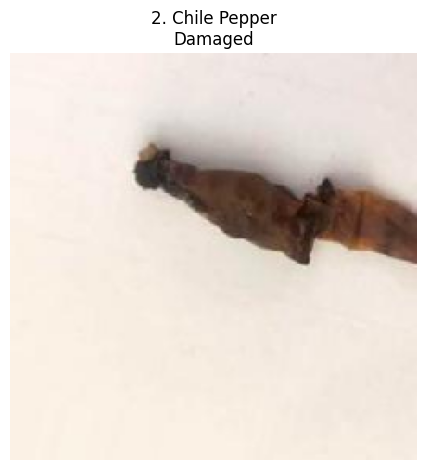

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Parametri
IMG_SIZE = (224, 224)
TEST_DIR = "/content/image_dataset_SE/split_dataset/test"

# Classi
fruit_class_names = ["1. Bell Pepper", "2. Chile Pepper", "3. New Mexico Green Chile", "4. Tomato"]
maturity_classes = ['Damaged', 'Dried', 'Old', 'Ripe', 'Unripe']

# Path Modelli TFLite
fruit_model_path = "/content/drive/MyDrive/ProgettoSE/models/fruit_type_classifier4.tflite"
maturity_model_paths = {
    "1. Bell Pepper": "/content/drive/MyDrive/ProgettoSE/models/maturity_bellpepper4.tflite",
    "2. Chile Pepper": "/content/drive/MyDrive/ProgettoSE/models/maturity_chilepepper4.tflite",
    "3. New Mexico Green Chile": "/content/drive/MyDrive/ProgettoSE/models/maturity_newmexchilepepper4.tflite",
    "4. Tomato": "/content/drive/MyDrive/ProgettoSE/models/maturity_tomato4.tflite"
}

# Funzione inferenza TFLite
def predict_tflite(model_path, img_array):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# Sceglie un'immagine random
main_class = random.choice(os.listdir(TEST_DIR))
subclass = random.choice(os.listdir(os.path.join(TEST_DIR, main_class)))
img_name = random.choice(os.listdir(os.path.join(TEST_DIR, main_class, subclass)))
img_path = os.path.join(TEST_DIR, main_class, subclass, img_name)

# Preprocessamento immagine
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array.astype(np.float32), axis=0)

# Predizione tipo di ortaggio
fruit_preds = predict_tflite(fruit_model_path, img_input)   # ha dimensione (1, num_classi), fruit_preds[0] accede alla prima (e unica) riga
fruit_idx = np.argmax(fruit_preds)                          # estrae indice con probabilità più alta
fruit_label = fruit_class_names[fruit_idx]                  # la sua label
fruit_conf = fruit_preds[0][fruit_idx]                      # la confidenza

# Predizione stato maturazione
maturity_model_path = maturity_model_paths[fruit_label]
maturity_preds = predict_tflite(maturity_model_path, img_input)
maturity_idx = np.argmax(maturity_preds)
maturity_label = maturity_classes[maturity_idx]
maturity_conf = maturity_preds[0][maturity_idx]

# Stampa risultati
print(f"🖼️ Immagine: {img_name}")
print(f"🔍 Vero: {main_class} / {subclass}")
print(f"🍓 Predetto: {fruit_label} ({fruit_conf:.2f}) / {maturity_label} ({maturity_conf:.2f})")

plt.imshow(img)
plt.axis('off')
plt.title(f"{fruit_label}\n{maturity_label}", fontsize=12)
plt.tight_layout()
plt.show()


**Inference on a single image saved in the drive**

🍓 Predizione frutto: 1. Bell Pepper (1.00)
🌡️ Predizione maturazione: Dried (1.00)


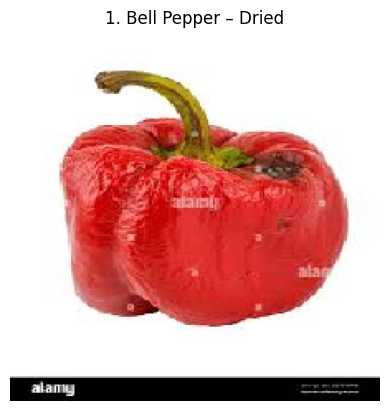

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Parametri
IMG_PATH = "/content/drive/MyDrive/download (1).jpg"
IMG_SIZE = (224, 224)

# Classi
fruit_class_names = ["1. Bell Pepper", "2. Chile Pepper", "3. New Mexico Green Chile", "4. Tomato"]
maturity_classes = ['Damaged', 'Dried', 'Old', 'Ripe', 'Unripe']

# Path Modelli TFlite
fruit_model_path = "/content/fruit_type_classifier4.tflite"
maturity_model_paths = {
    "1. Bell Pepper": "/content/maturity_bellpepper4.tflite",
    "2. Chile Pepper": "/content/maturity_chilepepper4.tflite",
    "3. New Mexico Green Chile": "/content/maturity_newmexchilepepper4.tflite",
    "4. Tomato": "/content/maturity_tomato4.tflite"
}

# Funzione di inferenza TFlite
def predict_tflite(model_path, img_array):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# Preprocessamento immagine
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array.astype(np.float32), axis=0)

# Predizione tipo di ortaggio
fruit_preds = predict_tflite(fruit_model_path, img_input)
fruit_pred_idx = np.argmax(fruit_preds)
fruit_pred_label = fruit_class_names[fruit_pred_idx]
fruit_confidence = fruit_preds[0][fruit_pred_idx]

# Predizione stato di maturazione
maturity_model_path = maturity_model_paths[fruit_pred_label]
maturity_preds = predict_tflite(maturity_model_path, img_input)
maturity_pred_idx = np.argmax(maturity_preds)
maturity_pred_label = maturity_classes[maturity_pred_idx]
maturity_confidence = maturity_preds[0][maturity_pred_idx]

# Stampa risultati
print(f"🍓 Predizione frutto: {fruit_pred_label} ({fruit_confidence:.2f})")
print(f"🌡️ Predizione maturazione: {maturity_pred_label} ({maturity_confidence:.2f})")


plt.imshow(img)
plt.title(f"{fruit_pred_label} – {maturity_pred_label}")
plt.axis('off')
plt.show()
